# Projekt z przedmiotu Obsługa Dużych Zbiorów Danych

## Tytuł projektu: Analiza wpływu liczby równoczesnych klientów na wydajność MongoDB Atlas

---

### Cel projektu

Zbadanie jak liczba równoczesnych połączeń (klientów) wpływa na wydajność operacji
w chmurowej bazie danych MongoDB Atlas. Projekt ma odpowiedzieć na pytanie:
**czy zwiększenie liczby klientów istotnie pogarsza metryki wydajności?**

---

### Hipoteza badawcza

**H0 (hipoteza zerowa):** Liczba równoczesnych klientów (1, 3, 5) nie wpływa istotnie
statystycznie na wydajność operacji MongoDB Atlas (latency, throughput, write performance).

**H1 (hipoteza alternatywna):** Wzrost liczby równoczesnych klientów istotnie statystycznie
wpływa na wydajność operacji - pogarsza latency i/lub zmniejsza throughput per klient.

**Poziom istotności:** α = 0.05

---

### Metodologia

1. Testy przeprowadzane dla 1, 3 i 5 równoczesnych klientów
2. Każdy klient wykonuje 100 operacji
3. **Każda konfiguracja testowana jest wielokrotnie (NUM_RUNS prób) dla zwiększenia wiarygodności statystycznej**
4. Klienci działają w osobnych procesach (multiprocessing) z własnymi połączeniami
5. Wyniki agregowane i porównywane testem ANOVA lub Kruskal-Wallis
6. Outliers usuwane metodą IQR przed analizą

## 1. Konfiguracja środowiska

In [1]:
# Importy bibliotek standardowych i zewnętrznych
import pymongo
import logging
import matplotlib.pyplot as plt
import statistics
import dotenv
import os

# Importy modułów projektu - metryki wydajności
from src.metrics.latency import latency
from src.metrics.throughput import throughput
from src.metrics.write_performance import write_performance

# Importy modułów projektu - narzędzia
from src.utils.filter_outliers import filter_outliers
from src.utils.statistical_importance import compare_multiple_groups
from src.utils.concurrent_test import run_concurrent_test, aggregate_latency_results, aggregate_throughput_results, aggregate_write_results
from src.utils.db_reset import CollectionStateManager, get_collection_count

# Wczytanie zmiennych środowiskowych (MONGO_URI)
dotenv.load_dotenv(dotenv_path="resources/secrets.env")

# Konfiguracja logowania-wyświetlanie timestampów i komunikatów
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(message)s",
)

In [2]:
# Parametry testów
# NUM_CLIENTS - lista liczby klientów do przetestowania
# OPERATIONS_PER_CLIENT - ile operacji wykonuje każdy klient
# NUM_RUNS - ile razy powtórzyć każdy test (próbki)
# DATABASE, COLLECTION-docelowa baza i kolekcja

NUM_CLIENTS = [1, 3, 5]
OPERATIONS_PER_CLIENT = 100
NUM_RUNS = 10  # Liczba powtórzeń testu dla każdej konfiguracji
DATABASE = "nieruchomosci"
COLLECTION = "boston"

# URI do MongoDB Atlas - pobrane z pliku .env
MONGO_URI = os.environ["MONGO_URI"]

print(f"Konfiguracja testów:")
print(f"  - Liczba klientów do testowania: {NUM_CLIENTS}")
print(f"  - Operacji per klient: {OPERATIONS_PER_CLIENT}")
print(f"  - Liczba prób (runów) per konfiguracja: {NUM_RUNS}")
print(f"  - Baza danych: {DATABASE}")
print(f"  - Kolekcja: {COLLECTION}")

Konfiguracja testów:
  - Liczba klientów do testowania: [1, 3, 5]
  - Operacji per klient: 100
  - Liczba prób (runów) per konfiguracja: 10
  - Baza danych: nieruchomosci
  - Kolekcja: boston


In [3]:
# Połączenie testowe-weryfikacja dostępu do bazy
client = pymongo.MongoClient(MONGO_URI)

print("Dostępne bazy danych:")
for name in client.list_database_names():
    print(f"  - {name}")

# Sprawdzenie liczby dokumentów w kolekcji testowej
initial_count = get_collection_count(client, DATABASE, COLLECTION)
print(f"\nLiczba dokumentów w {DATABASE}.{COLLECTION}: {initial_count}")

client.close()

Dostępne bazy danych:
  - firma
  - nieruchomosci
  - test
  - admin
  - local

Liczba dokumentów w nieruchomosci.boston: 4706


## 2. Test Latency (opóźnienia)

**Co mierzymy:** Czas odpowiedzi bazy na zapytanie find() - od wysłania żądania do otrzymania wyników.

**Oczekiwanie:** Przy większej liczbie klientów latency może wzrosnąć z powodu konkurencji o zasoby serwera.

In [4]:
# Słownik do przechowywania wyników latency dla każdej liczby klientów
# Struktura: {n_clients: {'all_runs': [...], 'per_run': [...]}}
latency_results = {}

for n_clients in NUM_CLIENTS:
    print(f"\n{'='*60}")
    print(f"TEST LATENCY: {n_clients} klient(ów) - {NUM_RUNS} prób")
    print(f"{'='*60}")
    
    all_measurements = []  # Wszystkie pomiary ze wszystkich runów
    per_run_stats = []  # Statystyki per run

    for run_idx in range(NUM_RUNS):
        print(f"\n  Próba {run_idx + 1}/{NUM_RUNS}...")

        # Uruchomienie testu z n_clients równoległymi klientami
        # Każdy klient wykonuje OPERATIONS_PER_CLIENT zapytań find()
        raw_results = run_concurrent_test(
            num_clients=n_clients,
            mongo_uri=MONGO_URI,
            task_func=latency,
            task_kwargs={
                "n": OPERATIONS_PER_CLIENT,
                "database": DATABASE,
                "collection": COLLECTION
            }
        )

        # Agregacja wyników od wszystkich klientów w tym runie
        aggregated = aggregate_latency_results(raw_results)
        all_measurements.extend(aggregated['all_runs'])
        per_run_stats.append({
            'run_idx': run_idx,
            'avg_latency_ms': aggregated['avg_latency_ms'],
            'num_measurements': len(aggregated['all_runs'])
        })
        print(f"    Średnia latency w próbie: {aggregated['avg_latency_ms']:.2f} ms")

    # Zapisz zagregowane wyniki
    latency_results[n_clients] = {
        'all_runs': all_measurements,
        'per_run': per_run_stats,
        'avg_latency_ms': statistics.mean([r['avg_latency_ms'] for r in per_run_stats])
    }

    print(f"\nWyniki dla {n_clients} klient(ów) ({NUM_RUNS} prób):")
    print(f"  Średnia latency: {latency_results[n_clients]['avg_latency_ms']:.2f} ms")
    print(f"  Łączna liczba pomiarów: {len(all_measurements)}")

2026-01-17 16:09:39,826 - Uruchamianie testu z 1 równoległymi klientami...



TEST LATENCY: 1 klient(ów) - 10 prób

  Próba 1/10...


2026-01-17 16:09:39,849 - Checking latency...
2026-01-17 16:09:44,081 - Time to fully execute find() 100 times: 42 ms
2026-01-17 16:09:44,125 - Test zakończony. Sukces: 1/1
2026-01-17 16:09:44,126 - Uruchamianie testu z 1 równoległymi klientami...


    Średnia latency w próbie: 42.30 ms

  Próba 2/10...


2026-01-17 16:09:44,145 - Checking latency...
2026-01-17 16:09:48,329 - Time to fully execute find() 100 times: 41 ms
2026-01-17 16:09:48,376 - Test zakończony. Sukces: 1/1
2026-01-17 16:09:48,377 - Uruchamianie testu z 1 równoległymi klientami...


...

    Średnia latency w próbie: 54.62 ms

  Próba 9/10...


2026-01-17 16:11:50,881 - Checking latency...
2026-01-17 16:11:50,881 - Checking latency...
2026-01-17 16:11:50,882 - Checking latency...
2026-01-17 16:11:50,882 - Checking latency...
2026-01-17 16:11:50,882 - Checking latency...
2026-01-17 16:11:56,083 - Time to fully execute find() 100 times: 51 ms
2026-01-17 16:11:56,124 - Time to fully execute find() 100 times: 52 ms
2026-01-17 16:11:56,129 - Time to fully execute find() 100 times: 52 ms
2026-01-17 16:11:56,139 - Time to fully execute find() 100 times: 52 ms
2026-01-17 16:11:56,211 - Time to fully execute find() 100 times: 53 ms
2026-01-17 16:11:56,263 - Test zakończony. Sukces: 5/5
2026-01-17 16:11:56,264 - Uruchamianie testu z 5 równoległymi klientami...


    Średnia latency w próbie: 52.53 ms

  Próba 10/10...


2026-01-17 16:11:56,308 - Checking latency...
2026-01-17 16:11:56,308 - Checking latency...
2026-01-17 16:11:56,308 - Checking latency...
2026-01-17 16:11:56,309 - Checking latency...
2026-01-17 16:11:56,309 - Checking latency...
2026-01-17 16:12:01,815 - Time to fully execute find() 100 times: 55 ms
2026-01-17 16:12:01,815 - Time to fully execute find() 100 times: 55 ms
2026-01-17 16:12:01,852 - Time to fully execute find() 100 times: 55 ms
2026-01-17 16:12:01,852 - Time to fully execute find() 100 times: 55 ms
2026-01-17 16:12:01,858 - Time to fully execute find() 100 times: 55 ms
2026-01-17 16:12:01,916 - Test zakończony. Sukces: 5/5


    Średnia latency w próbie: 55.28 ms

Wyniki dla 5 klient(ów) (10 prób):
  Średnia latency: 53.40 ms
  Łączna liczba pomiarów: 5000


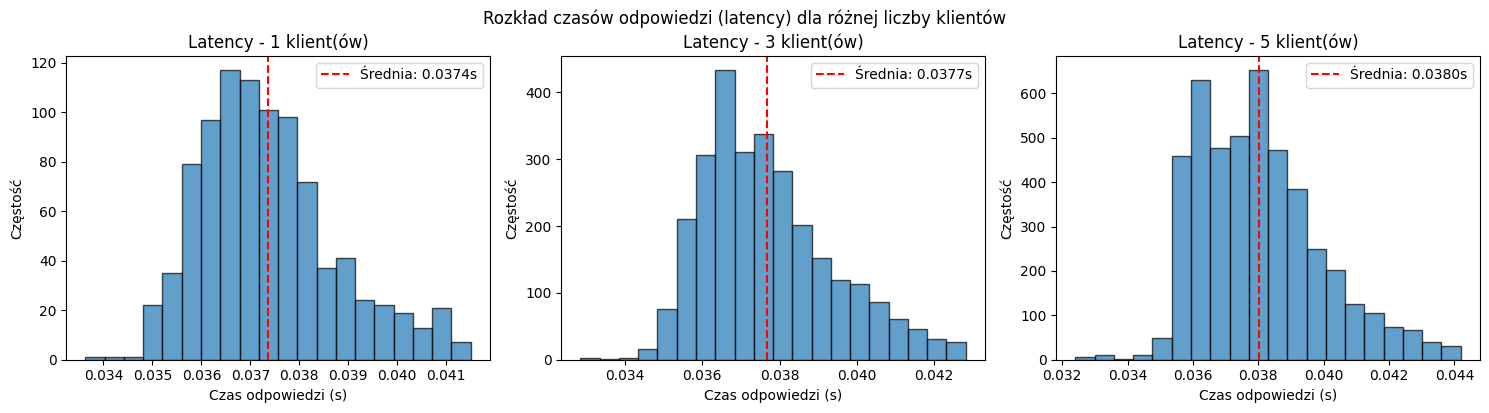

In [5]:
# Wizualizacja wyników latency
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, n_clients in enumerate(NUM_CLIENTS):
    data = latency_results[n_clients]['all_runs']
    filtered_data = filter_outliers(data)  # Usunięcie outlierów metodą IQR
    
    axes[idx].hist(filtered_data, bins=20, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Latency - {n_clients} klient(ów)')
    axes[idx].set_xlabel('Czas odpowiedzi (s)')
    axes[idx].set_ylabel('Częstość')
    
    # Dodanie linii średniej
    mean_val = statistics.mean(filtered_data)
    axes[idx].axvline(mean_val, color='red', linestyle='--', label=f'Średnia: {mean_val:.4f}s')
    axes[idx].legend()

plt.tight_layout()
plt.suptitle('Rozkład czasów odpowiedzi (latency) dla różnej liczby klientów', y=1.02)
plt.show()

In [6]:
# Test statystyczny-porównanie grup (ANOVA lub Kruskal-Wallis)
# WAŻNE: Porównujemy ŚREDNIE per run, nie wszystkie pomiary!
# Przy tysiącach pomiarów nawet minimalne różnice dają p ~= 0

latency_groups = {
    f"{n}_clients": [r['avg_latency_ms'] for r in latency_results[n]['per_run']]
    for n in NUM_CLIENTS
}

print("Dane do testu statystycznego: (średnie latency per run w ms")
for name, values in latency_groups.items():
    print(f"  - {name}: {[f'{v:.2f}' for v in values]}")

latency_stats = compare_multiple_groups(latency_groups)

2026-01-17 16:12:02,362 - ============================================================
2026-01-17 16:12:02,363 - PORÓWNANIE WIELU GRUP
2026-01-17 16:12:02,364 - ============================================================
2026-01-17 16:12:02,365 - Shapiro-Wilk dla '1_clients': p=0.303918 → normalny
2026-01-17 16:12:02,366 - Shapiro-Wilk dla '3_clients': p=0.123739 → normalny
2026-01-17 16:12:02,366 - Shapiro-Wilk dla '5_clients': p=0.085977 → normalny
2026-01-17 16:12:02,367 - 
Wszystkie grupy mają rozkład normalny → używam ANOVA (test_concurrent.ipynb F)
2026-01-17 16:12:02,368 - 
ANOVA: statystyka=469.8320, p-value=1.05e-21
2026-01-17 16:12:02,368 - ✓ WNIOSEK: Różnice między grupami SĄ istotne statystycznie (p < 0.05)
2026-01-17 16:12:02,369 -   Liczba klientów WPŁYWA na wydajność bazy danych.
2026-01-17 16:12:02,369 - ============================================================


Dane do testu statystycznego: (średnie latency per run w ms
  - 1_clients: ['42.30', '41.83', '41.45', '41.57', '41.75', '42.25', '42.67', '42.23', '41.39', '41.53']
  - 3_clients: ['42.18', '44.38', '42.41', '42.46', '43.45', '42.28', '43.05', '42.93', '42.01', '42.55']
  - 5_clients: ['51.97', '52.26', '53.46', '52.16', '54.09', '52.09', '55.50', '54.62', '52.53', '55.28']


In [7]:
# Podsumowanie statystyk latency
print("\nPODSUMOWANIE - LATENCY")
print("="*60)

for n_clients in NUM_CLIENTS:
    data = filter_outliers(latency_results[n_clients]['all_runs'])
    print(f"\n{n_clients} klient(ów):")
    print(f"  Średnia: {statistics.mean(data):.6f} s")
    print(f"  Mediana: {statistics.median(data):.6f} s")
    print(f"  Odch. std.: {statistics.stdev(data):.6f} s")
    print(f"  Min: {min(data):.6f} s")
    print(f"  Max: {max(data):.6f} s")


PODSUMOWANIE - LATENCY

1 klient(ów):
  Średnia: 0.037356 s
  Mediana: 0.037147 s
  Odch. std.: 0.001393 s
  Min: 0.033631 s
  Max: 0.041504 s

3 klient(ów):
  Średnia: 0.037685 s
  Mediana: 0.037392 s
  Odch. std.: 0.001683 s
  Min: 0.032845 s
  Max: 0.042815 s

5 klient(ów):
  Średnia: 0.038025 s
  Mediana: 0.037829 s
  Odch. std.: 0.001887 s
  Min: 0.032406 s
  Max: 0.044193 s


## 3. Test Throughput (przepustowości)

**Co mierzymy:** Liczbę operacji find_one() którą baza może obsłużyć na sekundę.

**Oczekiwanie:** Łączny throughput powinien rosnąć z liczbą klientów, ale niekoniecznie liniowo.

In [8]:
# Słownik do przechowywania wyników throughput
# Struktura podobna jak latency-z wieloma runami
throughput_results = {}

for n_clients in NUM_CLIENTS:
    print(f"\n{'='*60}")
    print(f"TEST THROUGHPUT: {n_clients} klient(ów) - {NUM_RUNS} prób")
    print(f"{'='*60}")
    
    all_measurements = []
    per_run_stats = []

    for run_idx in range(NUM_RUNS):
        print(f"\n  Próba {run_idx + 1}/{NUM_RUNS}...")

        raw_results = run_concurrent_test(
            num_clients=n_clients,
            mongo_uri=MONGO_URI,
            task_func=throughput,
            task_kwargs={
                "n": OPERATIONS_PER_CLIENT,
                "database": DATABASE,
                "collection": COLLECTION
            }
        )

        aggregated = aggregate_throughput_results(raw_results)
        all_measurements.extend(aggregated['all_runs'])
        per_run_stats.append({
            'run_idx': run_idx,
            'total_throughput': aggregated['total_throughput'],
            'avg_throughput_per_client': aggregated['avg_throughput_per_client']
        })
        print(f"    Throughput w próbie: {aggregated['total_throughput']:.2f} op/s")

    throughput_results[n_clients] = {
        'all_runs': all_measurements,
        'per_run': per_run_stats,
        'total_throughput': statistics.mean([r['total_throughput'] for r in per_run_stats]),
        'avg_throughput_per_client': statistics.mean([r['avg_throughput_per_client'] for r in per_run_stats])
    }

    print(f"\nWyniki dla {n_clients} klient(ów) ({NUM_RUNS} prób):")
    print(f"  Średni łączny throughput: {throughput_results[n_clients]['total_throughput']:.2f} op/s")
    print(f"  Średni throughput per klient: {throughput_results[n_clients]['avg_throughput_per_client']:.2f} op/s")

2026-01-17 16:12:02,469 - Uruchamianie testu z 1 równoległymi klientami...



TEST THROUGHPUT: 1 klient(ów) - 10 prób

  Próba 1/10...


2026-01-17 16:12:06,450 - Test zakończony. Sukces: 1/1
2026-01-17 16:12:06,453 - Uruchamianie testu z 1 równoległymi klientami...


    Throughput w próbie: 25.58 op/s

  Próba 2/10...


2026-01-17 16:12:10,393 - Test zakończony. Sukces: 1/1
2026-01-17 16:12:10,394 - Uruchamianie testu z 1 równoległymi klientami...


...

    Throughput w próbie: 91.48 op/s

  Próba 9/10...


2026-01-17 16:14:13,112 - Test zakończony. Sukces: 5/5
2026-01-17 16:14:13,113 - Uruchamianie testu z 5 równoległymi klientami...


    Throughput w próbie: 96.07 op/s

  Próba 10/10...


2026-01-17 16:14:18,966 - Test zakończony. Sukces: 5/5


    Throughput w próbie: 91.56 op/s

Wyniki dla 5 klient(ów) (10 prób):
  Średni łączny throughput: 94.25 op/s
  Średni throughput per klient: 18.85 op/s


2026-01-17 16:14:19,054 - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-17 16:14:19,055 - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-17 16:14:19,059 - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-17 16:14:19,060 - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


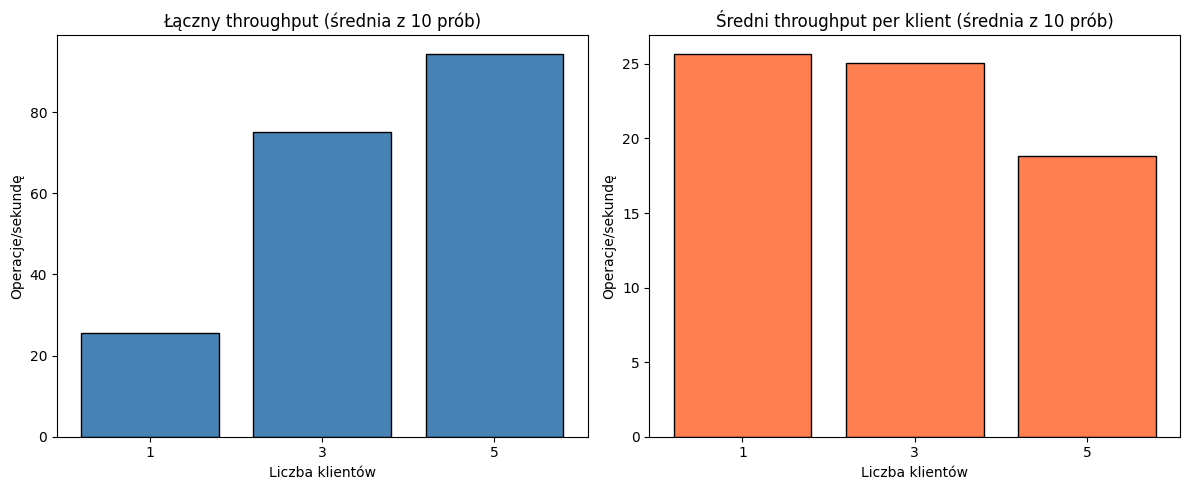

In [9]:
# Wizualizacja throughput-wykres słupkowy
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Wykres 1: Łączny throughput (średnia z wielu runów)
total_throughputs = [throughput_results[n]['total_throughput'] for n in NUM_CLIENTS]
axes[0].bar([str(n) for n in NUM_CLIENTS], total_throughputs, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Liczba klientów')
axes[0].set_ylabel('Operacje/sekundę')
axes[0].set_title(f'Łączny throughput (średnia z {NUM_RUNS} prób)')

# Wykres 2: Średni throughput per klient
avg_throughputs = [throughput_results[n]['avg_throughput_per_client'] for n in NUM_CLIENTS]
axes[1].bar([str(n) for n in NUM_CLIENTS], avg_throughputs, color='coral', edgecolor='black')
axes[1].set_xlabel('Liczba klientów')
axes[1].set_ylabel('Operacje/sekundę')
axes[1].set_title(f'Średni throughput per klient (średnia z {NUM_RUNS} prób)')

plt.tight_layout()
plt.show()

In [10]:
# Test statystyczny dla throughput
throughput_groups = {
    f"{n}_clients": [r['total_throughput'] for r in throughput_results[n]['per_run']]
    for n in NUM_CLIENTS
}

print("Dane do testu statystycznego Throughput: (łączny throughput per run w op/s)")
for name, values in throughput_groups.items():
    print(f"  - {name}: {[f'{v:.2f}' for v in values]}")

throughput_stats = compare_multiple_groups(throughput_groups)

2026-01-17 16:14:19,189 - ============================================================
2026-01-17 16:14:19,190 - PORÓWNANIE WIELU GRUP
2026-01-17 16:14:19,191 - ============================================================
2026-01-17 16:14:19,192 - Shapiro-Wilk dla '1_clients': p=0.000075 → nienormalny
2026-01-17 16:14:19,192 - Shapiro-Wilk dla '3_clients': p=0.763301 → normalny
2026-01-17 16:14:19,193 - Shapiro-Wilk dla '5_clients': p=0.270923 → normalny
2026-01-17 16:14:19,193 - 
Co najmniej jedna grupa ma rozkład nienormalny → używam Kruskal-Wallis
2026-01-17 16:14:19,195 - 
Kruskal-Wallis: statystyka=25.8065, p-value=2.49e-06
2026-01-17 16:14:19,196 - ✓ WNIOSEK: Różnice między grupami SĄ istotne statystycznie (p < 0.05)
2026-01-17 16:14:19,196 -   Liczba klientów WPŁYWA na wydajność bazy danych.
2026-01-17 16:14:19,197 - ============================================================


Dane do testu statystycznego Throughput: (łączny throughput per run w op/s)
  - 1_clients: ['25.58', '25.81', '25.74', '25.86', '25.69', '25.70', '24.69', '25.70', '25.87', '25.68']
  - 3_clients: ['76.57', '74.97', '74.47', '75.78', '74.79', '75.75', '73.27', '76.62', '74.58', '75.31']
  - 5_clients: ['93.66', '97.30', '94.04', '97.44', '91.59', '94.38', '95.01', '91.48', '96.07', '91.56']


## 4. Test Write Performance (wydajności zapisu)

**Co mierzymy:** Liczbę operacji insert_one() na sekundę.

**UWAGA:** Test zapisu modyfikuje dane w bazie! Używamy CollectionStateManager
do przywrócenia stanu kolekcji po testach (bezstanowość).

**Oczekiwanie:** Zapisy mogą być bardziej wrażliwe na konkurencję niż odczyty.

In [11]:
# Słownik do przechowywania wyników write performance
# Z wieloma runami i resetem stanu bazy
write_results = {}

# Połączenie do zarządzania stanem kolekcji
client = pymongo.MongoClient(MONGO_URI)

for n_clients in NUM_CLIENTS:
    print(f"\n{'='*60}")
    print(f"TEST WRITE PERFORMANCE: {n_clients} klient(ów) - {NUM_RUNS} prób")
    print(f"{'='*60}")
    
    all_measurements = []
    per_run_stats = []

    for run_idx in range(NUM_RUNS):
        print(f"\n  Próba {run_idx + 1}/{NUM_RUNS}...")

        # CollectionStateManager zapewnia reset bazy po teście
        # Zapisuje liczbę dokumentów przed testem i przywraca ją po
        with CollectionStateManager(client, DATABASE, COLLECTION):
            raw_results = run_concurrent_test(
                num_clients=n_clients,
                mongo_uri=MONGO_URI,
                task_func=write_performance,
                task_kwargs={
                    "n": OPERATIONS_PER_CLIENT,
                    "database": DATABASE,
                    "collection": COLLECTION
                }
            )

        aggregated = aggregate_write_results(raw_results)
        all_measurements.extend(aggregated['all_runs'])
        per_run_stats.append({
            'run_idx': run_idx,
            'total_write_throughput': aggregated['total_write_throughput'],
            'avg_write_throughput_per_client': aggregated['avg_write_throughput_per_client']
        })
        print(f"    Write throughput w próbie: {aggregated['total_write_throughput']:.2f} op/s")

    write_results[n_clients] = {
        'all_runs': all_measurements,
        'per_run': per_run_stats,
        'total_write_throughput': statistics.mean([r['total_write_throughput'] for r in per_run_stats]),
        'avg_write_throughput_per_client': statistics.mean([r['avg_write_throughput_per_client'] for r in per_run_stats])
    }

    print(f"\nWyniki dla {n_clients} klient(ów) ({NUM_RUNS} prób):")
    print(f"  Średni łączny write throughput: {write_results[n_clients]['total_write_throughput']:.2f} op/s")
    print(f"  Średni write throughput per klient: {write_results[n_clients]['avg_write_throughput_per_client']:.2f} op/s")

client.close()


TEST WRITE PERFORMANCE: 1 klient(ów) - 10 prób

  Próba 1/10...


2026-01-17 16:14:19,652 - Zapisano początkowy stan kolekcji nieruchomosci.boston: 4706 dokumentów
2026-01-17 16:14:19,653 - Uruchamianie testu z 1 równoległymi klientami...
2026-01-17 16:14:19,679 - Checking write performance for 100 operations...
2026-01-17 16:14:23,847 - Finished checking write performance...
2026-01-17 16:14:23,849 - Write performance: 23 operations per second...
2026-01-17 16:14:23,894 - Test zakończony. Sukces: 1/1
2026-01-17 16:14:23,939 - Resetowanie kolekcji nieruchomosci.boston: usuwanie 100 dokumentów (z 4806 do 4706)...
2026-01-17 16:14:24,025 - Usunięto 100 dokumentów.
2026-01-17 16:14:24,026 - Przywrócono stan kolekcji nieruchomosci.boston: usunięto 100 testowych dokumentów
2026-01-17 16:14:24,063 - Zapisano początkowy stan kolekcji nieruchomosci.boston: 4706 dokumentów
2026-01-17 16:14:24,064 - Uruchamianie testu z 1 równoległymi klientami...


    Write throughput w próbie: 23.99 op/s

  Próba 2/10...


2026-01-17 16:14:24,086 - Checking write performance for 100 operations...
2026-01-17 16:14:28,201 - Finished checking write performance...
2026-01-17 16:14:28,203 - Write performance: 24 operations per second...
2026-01-17 16:14:28,249 - Test zakończony. Sukces: 1/1
2026-01-17 16:14:28,292 - Resetowanie kolekcji nieruchomosci.boston: usuwanie 100 dokumentów (z 4806 do 4706)...
2026-01-17 16:14:28,376 - Usunięto 100 dokumentów.
2026-01-17 16:14:28,376 - Przywrócono stan kolekcji nieruchomosci.boston: usunięto 100 testowych dokumentów
2026-01-17 16:14:28,418 - Zapisano początkowy stan kolekcji nieruchomosci.boston: 4706 dokumentów
2026-01-17 16:14:28,419 - Uruchamianie testu z 1 równoległymi klientami...


    Write throughput w próbie: 24.30 op/s

  Próba 3/10...


...

    Write throughput w próbie: 47.14 op/s

  Próba 9/10...


2026-01-17 16:17:44,263 - Checking write performance for 100 operations...
2026-01-17 16:17:44,262 - Checking write performance for 100 operations...
2026-01-17 16:17:44,263 - Checking write performance for 100 operations...
2026-01-17 16:17:44,263 - Checking write performance for 100 operations...
2026-01-17 16:17:44,264 - Checking write performance for 100 operations...
2026-01-17 16:17:54,776 - Finished checking write performance...
2026-01-17 16:17:54,777 - Write performance: 9 operations per second...
2026-01-17 16:17:54,824 - Finished checking write performance...
2026-01-17 16:17:54,825 - Write performance: 9 operations per second...
2026-01-17 16:17:54,859 - Finished checking write performance...
2026-01-17 16:17:54,860 - Write performance: 9 operations per second...
2026-01-17 16:17:54,893 - Finished checking write performance...
2026-01-17 16:17:54,894 - Write performance: 9 operations per second...
2026-01-17 16:17:54,932 - Finished checking write performance...
2026-01-17 1

    Write throughput w próbie: 47.20 op/s

  Próba 10/10...


2026-01-17 16:17:55,736 - Checking write performance for 100 operations...
2026-01-17 16:17:55,737 - Checking write performance for 100 operations...
2026-01-17 16:17:55,737 - Checking write performance for 100 operations...
2026-01-17 16:17:55,737 - Checking write performance for 100 operations...
2026-01-17 16:17:55,738 - Checking write performance for 100 operations...
2026-01-17 16:18:05,757 - Finished checking write performance...
2026-01-17 16:18:05,758 - Write performance: 9 operations per second...
2026-01-17 16:18:05,792 - Finished checking write performance...
2026-01-17 16:18:05,793 - Write performance: 9 operations per second...
2026-01-17 16:18:05,951 - Finished checking write performance...
2026-01-17 16:18:05,951 - Finished checking write performance...
2026-01-17 16:18:05,953 - Write performance: 9 operations per second...
2026-01-17 16:18:05,953 - Write performance: 9 operations per second...
2026-01-17 16:18:06,515 - Finished checking write performance...
2026-01-17 1

    Write throughput w próbie: 48.79 op/s

Wyniki dla 5 klient(ów) (10 prób):
  Średni łączny write throughput: 47.45 op/s
  Średni write throughput per klient: 9.49 op/s


2026-01-17 16:18:06,882 - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-17 16:18:06,883 - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


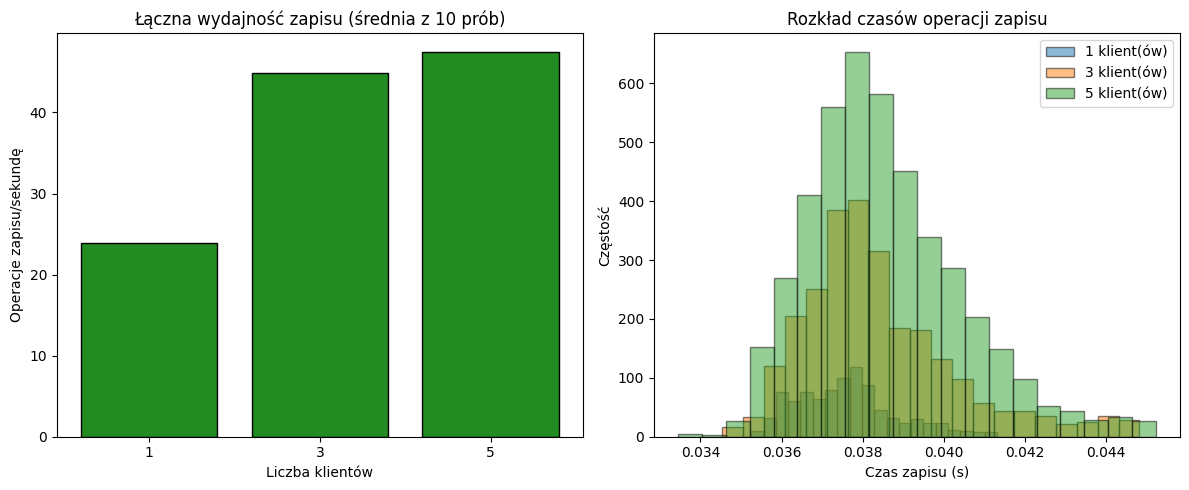

In [12]:
# Wizualizacja write performance
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Wykres 1: Łączny write throughput (średnia z runów)
total_writes = [write_results[n]['total_write_throughput'] for n in NUM_CLIENTS]
axes[0].bar([str(n) for n in NUM_CLIENTS], total_writes, color='forestgreen', edgecolor='black')
axes[0].set_xlabel('Liczba klientów')
axes[0].set_ylabel('Operacje zapisu/sekundę')
axes[0].set_title(f'Łączna wydajność zapisu (średnia z {NUM_RUNS} prób)')

# Wykres 2: Rozkład czasów zapisu
for n_clients in NUM_CLIENTS:
    data = filter_outliers(write_results[n_clients]['all_runs'])
    axes[1].hist(data, bins=20, alpha=0.5, label=f'{n_clients} klient(ów)', edgecolor='black')

axes[1].set_xlabel('Czas zapisu (s)')
axes[1].set_ylabel('Częstość')
axes[1].set_title('Rozkład czasów operacji zapisu')
axes[1].legend()

plt.tight_layout()
plt.show()

In [13]:
# Test statystyczny dla write performance
write_groups = {
    f"{n}_clients": [r['total_write_throughput'] for r in write_results[n]['per_run']]
    for n in NUM_CLIENTS
}

print("Dane do testu statystycznego Write: (łączny write throughput per run w op/s)")
for name, values in write_groups.items():
    print(f"  - {name}: {[f'{v:.2f}' for v in values]}")

write_stats = compare_multiple_groups(write_groups)

2026-01-17 16:18:07,095 - ============================================================
2026-01-17 16:18:07,096 - PORÓWNANIE WIELU GRUP
2026-01-17 16:18:07,096 - ============================================================
2026-01-17 16:18:07,097 - Shapiro-Wilk dla '1_clients': p=0.237886 → normalny
2026-01-17 16:18:07,097 - Shapiro-Wilk dla '3_clients': p=0.454804 → normalny
2026-01-17 16:18:07,098 - Shapiro-Wilk dla '5_clients': p=0.584760 → normalny
2026-01-17 16:18:07,098 - 
Wszystkie grupy mają rozkład normalny → używam ANOVA (test_concurrent.ipynb F)
2026-01-17 16:18:07,099 - 
ANOVA: statystyka=2924.8057, p-value=2.76e-32
2026-01-17 16:18:07,099 - ✓ WNIOSEK: Różnice między grupami SĄ istotne statystycznie (p < 0.05)
2026-01-17 16:18:07,099 -   Liczba klientów WPŁYWA na wydajność bazy danych.
2026-01-17 16:18:07,100 - ============================================================


Dane do testu statystycznego Write: (łączny write throughput per run w op/s)
  - 1_clients: ['23.99', '24.30', '24.19', '23.72', '23.82', '23.94', '23.77', '23.72', '23.12', '23.95']
  - 3_clients: ['46.46', '43.26', '44.17', '45.07', '44.56', '44.89', '44.92', '45.19', '44.72', '45.23']
  - 5_clients: ['48.05', '46.50', '47.40', '47.40', '49.19', '46.13', '46.72', '47.14', '47.20', '48.79']


## 5. Podsumowanie i wnioski

In [14]:
# Zestawienie wszystkich wyników
print("="*80)
print("PODSUMOWANIE WYNIKÓW TESTÓW WYDAJNOŚCI MONGODB ATLAS")
print("="*80)

print("\n" + "-"*80)
print("LATENCY (czas odpowiedzi na zapytanie)")
print("-"*80)
print(f"{'Klienci':<15} {'Średnia (s)':<15} {'Mediana (s)':<15} {'Std (s)':<15}")
for n in NUM_CLIENTS:
    data = filter_outliers(latency_results[n]['all_runs'])
    print(f"{n:<15} {statistics.mean(data):<15.6f} {statistics.median(data):<15.6f} {statistics.stdev(data):<15.6f}")
print(f"\nTest statystyczny: {latency_stats['test_used']}, p-value = {latency_stats['p_value']:.6f}")
print(f"Czy różnice są istotne statystycznie? {'TAK' if latency_stats['is_significant'] else 'NIE'}")

print("\n" + "-"*80)
print(f"THROUGHPUT (przepustowość odczytu) - średnie z {NUM_RUNS} prób")
print("-"*80)
print(f"{'Klienci':<15} {'Łączny (op/s)':<20} {'Per klient (op/s)':<20}")
for n in NUM_CLIENTS:
    print(f"{n:<15} {throughput_results[n]['total_throughput']:<20.2f} {throughput_results[n]['avg_throughput_per_client']:<20.2f}")
print(f"\nTest statystyczny: {throughput_stats['test_used']}, p-value = {throughput_stats['p_value']:.6f}")
print(f"Czy różnice są istotne statystycznie? {'TAK' if throughput_stats['is_significant'] else 'NIE'}")

print("\n" + "-"*80)
print(f"WRITE PERFORMANCE (wydajność zapisu) - średnie z {NUM_RUNS} prób")
print("-"*80)
print(f"{'Klienci':<15} {'Łączny (op/s)':<20} {'Per klient (op/s)':<20}")
for n in NUM_CLIENTS:
    print(f"{n:<15} {write_results[n]['total_write_throughput']:<20.2f} {write_results[n]['avg_write_throughput_per_client']:<20.2f}")
print(f"\nTest statystyczny: {write_stats['test_used']}, p-value = {write_stats['p_value']:.6f}")
print(f"Czy różnice są istotne statystycznie? {'TAK' if write_stats['is_significant'] else 'NIE'}")

PODSUMOWANIE WYNIKÓW TESTÓW WYDAJNOŚCI MONGODB ATLAS

--------------------------------------------------------------------------------
LATENCY (czas odpowiedzi na zapytanie)
--------------------------------------------------------------------------------
Klienci         Średnia (s)     Mediana (s)     Std (s)        
1               0.037356        0.037147        0.001393       
3               0.037685        0.037392        0.001683       
5               0.038025        0.037829        0.001887       

Test statystyczny: ANOVA, p-value = 0.000000
Czy różnice są istotne statystycznie? TAK

--------------------------------------------------------------------------------
THROUGHPUT (przepustowość odczytu) - średnie z 10 prób
--------------------------------------------------------------------------------
Klienci         Łączny (op/s)        Per klient (op/s)   
1               25.63                25.63               
3               75.21                25.07               
5        

In [15]:
# Wnioski końcowe
print("="*80)
print("WNIOSKI")
print("="*80)

significant_count = sum([
    latency_stats['is_significant'],
    throughput_stats['is_significant'],
    write_stats['is_significant']
])

print(f"\nLiczba metryk z istotnymi różnicami: {significant_count}/3")

if significant_count >= 2:
    print("\nODRZUCAMY H0: Liczba klientów ISTOTNIE wpływa na wydajność MongoDB Atlas.")
    print("  Wyniki wskazują, że zwiększenie liczby równoczesnych połączeń")
    print("  ma mierzalny wpływ na metryki wydajności bazy danych.")
elif significant_count == 1:
    print("\nWYNIKI NIEJEDNOZNACZNE: Tylko jedna metryka wykazuje istotne różnice.")
    print("  Potrzebne są dodatkowe badania z większą liczbą prób.")
else:
    print("\nBRAK PODSTAW DO ODRZUCENIA H0: Nie wykazano istotnego wpływu")
    print("  liczby klientów na wydajność MongoDB Atlas przy testowanym obciążeniu.")

print("\n" + "-"*80)
print("Szczegółowe obserwacje:")
print("-"*80)

# Analiza trendu latency
latency_1 = statistics.mean(filter_outliers(latency_results[1]['all_runs']))
latency_5 = statistics.mean(filter_outliers(latency_results[5]['all_runs']))
latency_change = ((latency_5 - latency_1) / latency_1) * 100
print(f"\n• Latency: zmiana {latency_change:+.1f}% między 1 a 5 klientami")

# Analiza trendu throughput per klient
tp_1 = throughput_results[1]['avg_throughput_per_client']
tp_5 = throughput_results[5]['avg_throughput_per_client']
tp_change = ((tp_5 - tp_1) / tp_1) * 100
print(f"• Throughput per klient: zmiana {tp_change:+.1f}% między 1 a 5 klientami")

# Analiza trendu write
write_1 = write_results[1]['avg_write_throughput_per_client']
write_5 = write_results[5]['avg_write_throughput_per_client']
write_change = ((write_5 - write_1) / write_1) * 100
print(f"• Write throughput per klient: zmiana {write_change:+.1f}% między 1 a 5 klientami")

# Dodatkowe info o próbach
print(f"\n• Liczba prób per konfiguracja: {NUM_RUNS}")
print(f"• Łączna liczba pomiarów per metryka: {NUM_RUNS * sum(NUM_CLIENTS) * OPERATIONS_PER_CLIENT}")

WNIOSKI

Liczba metryk z istotnymi różnicami: 3/3

ODRZUCAMY H0: Liczba klientów ISTOTNIE wpływa na wydajność MongoDB Atlas.
  Wyniki wskazują, że zwiększenie liczby równoczesnych połączeń
  ma mierzalny wpływ na metryki wydajności bazy danych.

--------------------------------------------------------------------------------
Szczegółowe obserwacje:
--------------------------------------------------------------------------------

• Latency: zmiana +1.8% między 1 a 5 klientami
• Throughput per klient: zmiana -26.5% między 1 a 5 klientami
• Write throughput per klient: zmiana -60.2% między 1 a 5 klientami

• Liczba prób per konfiguracja: 10
• Łączna liczba pomiarów per metryka: 9000


---

## Załączniki

### Użyte metryki:
- **Latency** - czas odpowiedzi bazy na zapytanie find()
- **Throughput** - liczba operacji find_one() na sekundę
- **Write Performance** - liczba operacji insert_one() na sekundę

### Metody statystyczne:
- **Shapiro-Wilk** - test normalności rozkładu
- **ANOVA** - porównanie średnich wielu grup (dla danych normalnych)
- **Kruskal-Wallis** - nieparametryczny odpowiednik ANOVA
- **IQR** - metoda usuwania outlierów (wartości odstających)

### Środowisko testowe:
- MongoDB Atlas (chmura)
- Python 3.x z pymongo
- Multiprocessing dla symulacji wielu klientów